In [1]:
import sys

sys.path.append("../src/")

from constants import INPT_VARS, EXTRA_VARS, OUT_VARS
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation

from utils.train_utils import extract_wet
from utils.data_utils import (
    get_train_test_ranges,
    data_CNN_Disk,
    data_CNN_Disk_steps,
    gen_3D_data,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_KE,
    compute_nino34,
    compute_amo,
    gen_KE_range,
    gen_value_range,
    compute_mean_single,
)
from utils.climate_utils import compute_laplacian_wet

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
import copy
from datetime import datetime
import os

In [6]:
# ########################################################
# 1 2002
# All Levels - Hist = 1, HFDS Anom, 100 year emulation, 1975, NetZeroHf
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all_hfds_anoms",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_2002".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_2002".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/from_greene/hist1_hfds_anom_1975/convnextunet_epoch_55_steps_4_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "N_samples=0",
#             "N_val=0",
#             "N_test=29200",
#             "data_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_2002_netzerohf",
#             "data_means_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_means",
#             "data_stds_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_stds",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4_2002_repeat",
#             "+save_factor=200",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

# ########################################################
# 2 2002 Temp Only
# All Levels - Hist = 1, HFDS Anom, 100 year emulation, 1975, TempOnly, NetZeroHf
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all_hfds_anoms",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_2002".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_2002".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-09-09-convnextunet_v021_hist1_hfds_anom_1975_nofast/nofast/saved_nets/convnextunet_epoch_55_beststeps_4_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "N_samples=0",
#             "N_val=0",
#             "N_test=29200",
#             "data_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_2002_netzerohf",
#             "data_means_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_means",
#             "data_stds_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_stds",
#             "exp_num_in=3D_noFast_all",
#             "exp_num_out=3D_noFast_all",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4_2002_repeat",
#             "+save_factor=200",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )
# ########################################################
# 3 1998
# All Levels - Hist = 1, HFDS Anom, 100 year emulation, 1975, NetZeroHf
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all_hfds_anoms",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_1998".format(
#                 str("2024-09-25")[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_1998".format(
#                 str("2024-09-25")[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/from_greene/hist1_hfds_anom_1975/convnextunet_epoch_55_steps_4_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "N_samples=0",
#             "N_val=0",
#             "N_test=29200",
#             "data_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_1998_netzerohf",
#             "data_means_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_means",
#             "data_stds_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_stds",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4_1998_repeat",
#             "+save_factor=200",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
    # )

# ########################################################
# 4 1998 Temp Only
# All Levels - Hist = 1, HFDS Anom, 100 year emulation, 1975, TempOnly, NetZeroHf
with initialize_config_dir(
    version_base=None,
    config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
):
    args = compose(
        config_name="exp/eval_unet_global_3D_all_hfds_anoms",
        overrides=[
            "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_1998".format(
                str(datetime.now())[:10]
            ),
            "network={0}_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_1998".format(
                str(datetime.now())[:10]
            ),
            "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-09-09-convnextunet_v021_hist1_hfds_anom_1975_nofast/nofast/saved_nets/convnextunet_epoch_55_beststeps_4_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth.pt]",
            "hist=1",
            "unet.ch_width=[157,200,250,300,400]",
            "run_gen_pred=True",
            "N_samples=0",
            "N_val=0",
            "N_test=29200",
            "data_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_1998_netzerohf",
            "data_means_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_means",
            "data_stds_zarr=3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_stds",
            "exp_num_in=3D_noFast_all",
            "exp_num_out=3D_noFast_all",
            "pred_names=null",
            "pred_paths=null",
            "+dataset_name=OM4_1998_repeat",
            "+save_factor=200",
            "train_region=global_3D",
            "region=global_3D",
            "model_name_replace=Convnext",
            "depth_mode=all",
        ],
    )

In [7]:
inputs_str = INPT_VARS[args.exp_num_in]
extra_in_str = EXTRA_VARS[args.exp_num_extra]
outputs_str = OUT_VARS[args.exp_num_out]
levels = args.exp_num_in.split("_")[-1]
if "all" in levels:
    levels = 19
elif "2D" in levels:
    levels = 1
else:
    levels = int(levels)

str_in = "".join([i + "_" for i in inputs_str])
str_ext = "".join([i + "_" for i in extra_in_str])
str_out = "".join([i + "_" for i in outputs_str])

print("inputs: " + str_in)
print("extra inputs: " + str_ext)
print("outputs: " + str_out)
print("levels: " + str(levels))

N_atm = len(extra_in_str)  # Number of atmosphere variables
N_in = len(inputs_str)
if args.lateral:
    N_extra = (
        N_atm + N_in
    )  # Number of atmosphere variables + Lateral boundary variables
else:
    N_extra = N_atm  # Number of atmosphere variables
N_out = len(outputs_str)

num_in = int((args.hist + 1) * N_in + N_extra)
num_out = int((args.hist + 1) * len(outputs_str))

print("Number of inputs: ", num_in)  # 3 (ocean speeds + ocean temp)(t) +
# 3 (atm wind stresses + atm temp)(t) +
# 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
print("Number of outputs: ", num_out)  # 3

if "swin" in args.network.lower():
    pass
    # model = instantiate(
    #     args.swin,
    #     in_channels=num_in,
    #     output_channels=num_out,
    #     pretrain_img_size=[180, 360],
    #     wet=wet.cuda(),
    #     hist=args.hist,
    # )
elif "convnext" in args.network.lower():
    if args.unet.ch_width[0] != num_in:
        print(
            "Changing ch_width to match number of inputs {0} -> {1}".format(
                args.unet.ch_width[0], num_in
            )
        )
        args.unet.ch_width[0] = num_in

# Post-fix strings
str_train = (
    "steps_"
    + str(args.steps)
    + "_"
    + args.train_region
    + "_"
    + args.depth_mode
    + "_N_train_4000"
    + "_Lateral_Data_025_no_smooth"
)
str_save = (
    "steps_"
    + str(args.steps)
    + "_"
    + args.train_region
    + "_"
    + args.region
    + "_"
    + args.depth_mode
    + "+N_samples_"
    + str(args.N_samples)
)
post_model_name = (
    "Train_"
    + args.train_region
    + "_Test_"
    + args.region
    + "_"
    + args.depth_mode
    + "_N_train_"
    + str(args.N_samples)
    + "_Lateral_Data_025_no_smooth"
)
post_pred_name = (
    args.region + "_" + args.depth_mode + "_N_samples_" + str(args.N_samples)
)

# Getting start and end indices of train and test
s_train, e_train, e_test = get_train_test_ranges(
    args.N_samples, args.N_val, args.lag, args.hist, args.interval
)
dataset_name = args.dataset_name

if "OM4" in dataset_name:
    timestep_str = "\\times 5"
else:
    raise ValueError("Dataset not recognized")


print("Calculating mask tensors")
wet_zarr = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", args.wet_file))
wet = extract_wet(wet_zarr, outputs_str, args.hist)
print("Wet resolution:", wet.shape)
print("e_test: ", e_test)

inputs: thetao_lev_2_5_thetao_lev_10_0_thetao_lev_22_5_thetao_lev_40_0_thetao_lev_65_0_thetao_lev_105_0_thetao_lev_165_0_thetao_lev_250_0_thetao_lev_375_0_thetao_lev_550_0_thetao_lev_775_0_thetao_lev_1050_0_thetao_lev_1400_0_thetao_lev_1850_0_thetao_lev_2400_0_thetao_lev_3100_0_thetao_lev_4000_0_thetao_lev_5000_0_thetao_lev_6000_0_so_lev_2_5_so_lev_10_0_so_lev_22_5_so_lev_40_0_so_lev_65_0_so_lev_105_0_so_lev_165_0_so_lev_250_0_so_lev_375_0_so_lev_550_0_so_lev_775_0_so_lev_1050_0_so_lev_1400_0_so_lev_1850_0_so_lev_2400_0_so_lev_3100_0_so_lev_4000_0_so_lev_5000_0_so_lev_6000_0_zos_
extra inputs: tauuo_tauvo_hfds_hfds_anomalies_
outputs: thetao_lev_2_5_thetao_lev_10_0_thetao_lev_22_5_thetao_lev_40_0_thetao_lev_65_0_thetao_lev_105_0_thetao_lev_165_0_thetao_lev_250_0_thetao_lev_375_0_thetao_lev_550_0_thetao_lev_775_0_thetao_lev_1050_0_thetao_lev_1400_0_thetao_lev_1850_0_thetao_lev_2400_0_thetao_lev_3100_0_thetao_lev_4000_0_thetao_lev_5000_0_thetao_lev_6000_0_so_lev_2_5_so_lev_10_0_so_lev_22

In [8]:
import xarray as xr
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
from scipy.ndimage import gaussian_filter
from einops import rearrange
import os

class data_CNN_Disk(torch.utils.data.Dataset):

    def __init__(
        self,
        data,
        inputs_str,
        extra_in_str,
        outputs_str,
        wet,
        data_mean,
        data_std,
        n_samples,
        lag,
        interval,
        hist,
        ind_start,
        long_rollout,
        device="cuda",
    ):
        super().__init__()
        self.device = device

        self.size = n_samples
        self.lag = lag
        self.interval = interval
        self.hist = hist
        self.ind_start = ind_start

        assert self.interval == 1
        assert self.lag == 1

        data = data.isel(time=slice(self.ind_start, None))
        self.inputs = data[inputs_str + extra_in_str]
        self.outputs = data[outputs_str]
        self.inputs_no_extra = data[inputs_str]
        self.extras = data[extra_in_str]

        # This class will be used only for validation and rollouts
        # Rolling indices to keep track of histories/past states:
        # HIST=0 ; 0->[0, 1]; 1->[1, 2]; 2->[2, 3]; 3->[3, 4]
        # HIST=1 ; 0->[[0, 1], [2, 3]]; 1->[[2, 3], [4, 5]]; 2->[[4, 5], [6, 7]]; 3->[[6, 7], [8, 9]]
        # HIST=2 ; 0->[[0, 1, 2], [3, 4, 5]]; 1->[[3, 4, 5], [6, 7, 8]]; 2->[[6, 7, 8], [9, 10, 11]]; 3->[[9, 10, 11], [12, 13, 14]]
        indices = xr.DataArray(
            np.arange(data.time.size),
            dims=["time"],
            coords={"time": data.time},
        )
        total_steps = 2 * self.hist + 1
        rolling_indices = (
            indices.rolling(time=len(data.time) - total_steps, center=False)
            .construct("window_dim")
            .astype(int)
        )
        rolling_indices = rolling_indices.transpose("window_dim", "time").isel(
            time=slice(len(data.time) - total_steps - 1, None)
        )  # Remove first few null indices
        self.rolling_indices = rolling_indices.isel(
            window_dim=slice(0, None, self.hist + 1)
        )  # Skip indices based on history

        if long_rollout:
            window0 = self.rolling_indices.isel(window_dim=0)
            print(
                "Long rollout will begin with input and produce output from time index {0} and {1} respectively".format(
                    window0.isel(time=0).values + ind_start,
                    window0.isel(time=self.hist + 1).values + ind_start,
                )
            )

        self.in_mean = data_mean[inputs_str + extra_in_str]
        self.in_std = data_std[inputs_str + extra_in_str]
        self.out_mean = data_mean[outputs_str]
        self.out_std = data_std[outputs_str]
        self.inputs_no_extra_mean = data_mean[inputs_str]
        self.inputs_no_extra_std = data_std[inputs_str]
        self.extras_mean = data_mean[extra_in_str]
        self.extras_std = data_std[extra_in_str]

        self.wet = wet

    def set_device(self, device):
        self.device = device

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        if type(idx) == slice:
            if idx.start == None and idx.stop == None:
                idx = slice(0, self.size, idx.step)
            elif idx.start == None:
                idx = slice(0, idx.stop, idx.step)
            elif idx.stop == None:
                idx = slice(idx.start, self.size, idx.step)
        elif type(idx) == int:
            idx = slice(idx, idx + 1, 1)

        rolling_idx = self.rolling_indices.isel(window_dim=idx)
        x_index = xr.Variable(
            ["window_dim", "time"], rolling_idx
        )
        print("Out: ", (self.ind_start + x_index.isel(time=slice(self.hist + 1, None))).values, end=' ')
        data_in = self.inputs_no_extra.isel(time=x_index).isel(
            time=slice(None, self.hist + 1)
        )
        data_in = (
            (data_in - self.inputs_no_extra_mean) / self.inputs_no_extra_std
        ).fillna(0)
        data_in = (
            data_in.to_array()
            .transpose("window_dim", "time", "variable", "y", "x")
            .to_numpy()
        )
        data_in = rearrange(
            data_in, "window_dim time variable y x -> window_dim (time variable) y x"
        )
        if len(self.extras.variables) != 0:
            data_in_boundary = self.extras.isel(time=x_index).isel(time=self.hist)
            data_in_boundary = (
                (data_in_boundary - self.extras_mean) / self.extras_std
            ).fillna(0)
            data_in_boundary = (
                data_in_boundary.to_array()
                .transpose("window_dim", "variable", "y", "x")
                .to_numpy()
            )
            data_in = np.concatenate((data_in, data_in_boundary), axis=1)

        label = self.outputs.isel(time=x_index).isel(time=slice(self.hist + 1, None))
        label = ((label - self.out_mean) / self.out_std).fillna(0)
        label = (
            label.to_array()
            .transpose("window_dim", "time", "variable", "y", "x")
            .to_numpy()
        )
        label = rearrange(
            label, "window_dim time variable y x -> window_dim (time variable) y x"
        )

        items = (torch.from_numpy(data_in).float(), torch.from_numpy(label).float())

        return items

In [9]:
from cftime import DatetimeProlepticGregorian
from datetime import timedelta
start_year = 1990
dates = np.array(range(3, 365*100, 5))
base = DatetimeProlepticGregorian(1990,1,1)
all_dates = [base + timedelta(days=int(day-1)) for day in dates]

data = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", "3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975"))
ds_groundtruth = data.sel(time=slice("1990-01-01", "1999-12-31"))
ds_groundtruth = xr.concat([ds_groundtruth] * 10, dim="time")
ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(np.arange(ds_groundtruth.time.size)* (0.0136986301),(-1,1,1))
ds_groundtruth = ds_groundtruth.assign_coords(time=all_dates[:ds_groundtruth.time.size])
ds_groundtruth.time

<xarray.DataArray 'time' (time: 7300)>
array([cftime.DatetimeProlepticGregorian(1990, 1, 3, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(1990, 1, 8, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(1990, 1, 13, 0, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeProlepticGregorian(2089, 11, 24, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2089, 11, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2089, 12, 4, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 1990-01-03 00:00:00 ... 2089-12-04 00:00:00

<xarray.DataArray 'polyfit_coefficients' ()>
array(0.8694794)
Coordinates:
    degree   int64 1
<xarray.DataArray 'polyfit_coefficients' ()>
array(0.07321344)
Coordinates:
    degree   int64 1


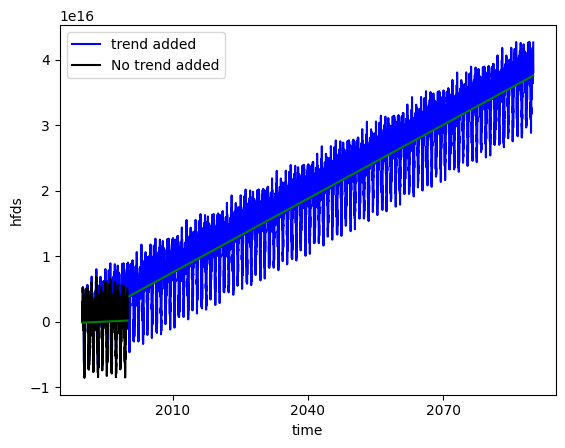

In [13]:
import matplotlib.pyplot as plt
for var in ['hfds']:
    # Plotting
    dim = 'time'
    title = 'hfds'
    
    hfds_timeseries_1wm2 = ds_groundtruth[var].weighted(data['areacello']).sum(['x', 'y'])
    
    # Yearly average
    # hfds_timeseries_1wm2 = hfds_timeseries_1wm2.groupby('time.year').mean('time')
    # dim = 'year'
    # title = f'{var} yearly averaged'
    
    hfds_timeseries_1wm2.plot(c='b', label='trend added')
    poly_coeffs = hfds_timeseries_1wm2.polyfit(dim=dim, deg=1).compute()
    trend = xr.polyval(hfds_timeseries_1wm2[dim], poly_coeffs.polyfit_coefficients).compute()
    trend.plot(c='g')
    print(poly_coeffs.polyfit_coefficients[0]*73)
    
    hfds_timeseries = data[var].sel(time=slice("1990-01-01", "1999-12-31")).weighted(data['areacello']).sum(['x', 'y'])
    # Yearly average
    # hfds_timeseries = hfds_timeseries.groupby('time.year').mean('time')
    # dim = 'year'
    # title = f'{var} yearly averaged'
    
    hfds_timeseries.plot(c='k', label='No trend added')
    poly_coeffs = hfds_timeseries.polyfit(dim=dim, deg=1).compute()
    trend = xr.polyval(hfds_timeseries[dim], poly_coeffs.polyfit_coefficients).compute()
    trend.plot(c='g')
    print(poly_coeffs.polyfit_coefficients[0]*73)
    
    plt.legend()
    plt.ylabel(title)

In [5]:
# 0.0136986301 / 4

In [6]:
import xarray as xr

assert args.depth_mode == "surface" or args.depth_mode == "all"

data = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", args.data_zarr))
if args.data_zarr== "3D_data_OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_netzerohfds_nojump3xcc":
    print("Updating climate forced runs!")
    data['hfds'] = data['hfds'] + .017462726 
    data['hfds_anomalies'] = data['hfds_anomalies'] + .017462726 
    data['hfds'] = data['hfds'] + np.reshape(np.arange(data.time.size)* (0.0136986301-4.01369026e-04),(-1,1,1))
    data['hfds_anomalies'] = data['hfds_anomalies'] + np.reshape(np.arange(data.time.size)* (0.0136986301-4.01369026e-04),(-1,1,1))


In [7]:
repeats = 4
data = xr.concat([data] * repeats, dim="time")
data['time'] = np.arange(data.time.size)
data

<xarray.Dataset>
Dimensions:            (y: 180, x: 360, lev: 19, time: 29200, y_b: 181, x_b: 361)
Coordinates:
    areacello          (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                 (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b              (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b              (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction     (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time               (time) int64 0 1 2 3 4 ... 29195 29196 29197 29198 29199
    wetmask            (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                  (x) float64 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y                  (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables: (12/81)
    hfds               (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies     (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1050_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_105_0       (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_10_0        (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1400_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                 ...
    vo_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_550_0       (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_65_0        (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_775_0       (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [8]:

data_mean = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", args.data_means_zarr)
)
data_std = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", args.data_stds_zarr)
)
train_data = data_CNN_Disk_steps(
    data,
    inputs_str,
    extra_in_str,
    outputs_str,
    wet,
    data_mean,
    data_std,
    args.N_samples,
    args.lag,
    args.interval,
    args.hist,
    args.steps,
    device="cuda",
)

test_data = data_CNN_Disk(
    data,
    inputs_str,
    extra_in_str,
    outputs_str,
    wet,
    data_mean,
    data_std,
    data.time.size,
    args.lag,
    args.interval,
    args.hist,
    e_test,
    long_rollout=True,
    device="cuda",
)
# test_data[0]



/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 1 and 3 respectively


In [9]:
# Model
print("Loading model " + args.network)
if "swin" in args.network.lower():
    model = instantiate(
        args.swin,
        in_channels=num_in,
        output_channels=num_out,
        pretrain_img_size=[180, 360],
        wet=wet.cuda(),
        hist=args.hist,
    )
elif "unet" in args.network.lower():
    model = instantiate(args.unet, n_out=num_out, wet=wet.cuda(), hist=args.hist)

full_model_path = args.ckpt_path
full_model_name = args.network + "_" + post_model_name
output_channels = model.output_channels

model = model.to(args.device)
ckpt_path = args.ckpt_path
model = model

# Stats
mean_in = test_data.in_mean.to_array().to_numpy().reshape(-1)
std_in = test_data.in_std.to_array().to_numpy().reshape(-1)
mean_out = test_data.out_mean.to_array().to_numpy().reshape(-1)
std_out = test_data.out_std.to_array().to_numpy().reshape(-1)

test_data.norm_vals = {
    "s_out": std_out,
    "s_in": std_in,
    "m_out": mean_out,
    "m_in": mean_in,
}

# Getting area tensor
print("Computing area tensor")
grids = xr.open_dataset(os.path.join("/pscratch/sd/s/suryad/data", args.grid_file)).rename({"xu_ocean": "x", "yu_ocean": "y"})

area = torch.from_numpy(grids["area_C"].to_numpy()).to(device="cpu")
pred_model_path = Path("/pscratch/sd/s/suryad/Ocean_Emulator/Preds") / full_model_name
if not os.path.isdir(pred_model_path):
    os.makedirs(pred_model_path)

Nb = args.Nb
hist = args.hist
lag = args.lag
N_test = args.N_test
N_samples = args.N_samples
output_dir = args.output_dir
region = args.region
steps = args.steps
network = args.model_name_replace

pred_region = args.region
pred_names = args.pred_names if args.pred_names else []
pred_paths = args.pred_paths if args.pred_paths else []

JUPYTER_MODE = False
    
    


Loading model 2024-09-26_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_1998
Computing area tensor


In [10]:
out_mean = torch.tensor(test_data.out_mean.to_array().to_numpy()).to(device="cuda")
out_std = torch.tensor(test_data.out_std.to_array().to_numpy()).to(device="cuda")

In [11]:
### Generate
def generate_pred_lateral():
    print("Generation Pred begin...")
    for rand_ind, model_path in enumerate(args.ckpt_path):
        print("Random seed: ", rand_ind + 1)
        # try:
        model.load_state_dict(
            torch.load(model_path, map_location=torch.device("cuda"))["model"]
        )
        # except:
        #     model.load_state_dict(
        #         torch.load(model_path, map_location=torch.device("cuda"))
        #     )
        pred_path = pred_model_path / (
                        "Pred_lateral_Fast_Data_025_"
                        + post_pred_name
                        + "_rand_seed_"
                        + str(rand_ind + 1)
                        + ".zarr"
                    )
        save_factor = args.save_factor
        print(f"Using save_factor {save_factor} to produce {N_test // save_factor} steps each iteration")
        outs = None
        if not os.path.isdir(pred_path):
            start = 0
            print(f"Starting save from {start} for Pred path {pred_path}")
            initial_input = None
        else:
            pred = xr.open_zarr(pred_path)
            start = pred.time.size
            print(f"Restarting save from {start} for Pred path {pred_path}")
            last_pred_numpy = pred.isel(time=slice(-2,None)).to_array().to_numpy().squeeze()
            last_pred = torch.tensor(last_pred_numpy).to(device="cuda")
            assert last_pred.shape[:3] == torch.Size([2, 180, 360])
            last_pred = (last_pred - out_mean) / out_std
            initial_input = torch.swapaxes(torch.swapaxes(last_pred, 3, 2), 2, 1).reshape(-1, 180, 360)
            

        for i in range(start, N_test, N_test // save_factor):
            start_time = time.time()
            test_data = data_CNN_Disk(
                data,
                inputs_str,
                extra_in_str,
                outputs_str,
                wet,
                data_mean,
                data_std,
                args.N_test,
                args.lag,
                args.interval,
                args.hist,
                e_test + i,
                long_rollout=True,
                device="cuda",
            )
            
            test_data.norm_vals = {
                "s_out": std_out,
                "s_in": std_in,
                "m_out": mean_out,
                "m_in": mean_in,
            }
            if outs is not None:
                initial_input = outs[-1]
                
            model_pred, outs = generate_model_rollout(
                N_test // save_factor,
                test_data,
                model,
                hist,
                N_in,
                N_extra,
                initial_input,
                Nb,
                region,
            )
            da = xr.DataArray(
                data=model_pred,
                dims=["time", "x", "y", "var"],
            )

            if i == 0:
                da.to_zarr(pred_path, mode="w")
            else:
                da.to_zarr(pred_path, mode="a", append_dim="time")
            print("Saved: ", i, " to ", i + N_test // save_factor)
            print(f"Time taken for generating {N_test // save_factor} predictions: {time.time() - start_time} seconds")


In [ ]:
import time 
start_time = time.time()
if args.run_gen_pred:
    generate_pred_lateral()
    
print(f"Time taken for generating {N_test} predictions: {time.time() - start_time} seconds")

Generation Pred begin...
Random seed:  1
Using save_factor 200 to produce 146 steps each iteration
Starting save from 0 for Pred path /pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-26_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_1998_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 1 and 3 respectively
Out:  [[3 4]] Out:  [[3 4]] Out:  [[5 6]] Out:  [[7 8]] Out:  [[ 9 10]] Out:  [[11 12]] Out:  [[13 14]] Out:  [[15 16]] Out:  [[17 18]] Out:  [[19 20]] Out:  [[21 22]] Out:  [[23 24]] Out:  [[25 26]] Out:  [[27 28]] Out:  [[29 30]] Out:  [[31 32]] Out:  [[33 34]] Out:  [[35 36]] Out:  [[37 38]] Out:  [[39 40]] Out:  [[41 42]] Out:  [[43 44]] Out:  [[45 46]] Out:  [[47 48]] Out:  [[49 50]] Out:  [[51 52]] Out:  [[53 54]] Out:  [[55 56]] Out:  [[57 58]] Out:  [[59 60]] Out:  [[61 62]] Out:  [[63 64]] Out:  [[65 66]] Out:  [[67 68]] Out:  [[69 70]] Out:  [[71 72]] Out:  [[73 74]] Out:  [[75 76]] Out:  [[77 78]] Out:  [[79 80]] Out:  [[81 82]] Out:  [[83 84]] Out:  [[85 86]] Out:  [[87 88]] Out:  [[89 90]] Out:  [[91 92]] Out:  [[93 94]] Out:  [[95 96]] Out:  [[97 98]] Out:  [[ 99 100]] Out:  [[101 102]] Out:  [[103 104]] Out:  [[105 106]] Out:  [[107 108]] Out:  [[109 110]] Out:  [[111 112]] Out:  [

/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 147 and 149 respectively
Out:  [[149 150]] Out:  [[149 150]] Out:  [[151 152]] Out:  [[153 154]] Out:  [[155 156]] Out:  [[157 158]] Out:  [[159 160]] Out:  [[161 162]] Out:  [[163 164]] Out:  [[165 166]] Out:  [[167 168]] Out:  [[169 170]] Out:  [[171 172]] Out:  [[173 174]] Out:  [[175 176]] Out:  [[177 178]] Out:  [[179 180]] Out:  [[181 182]] Out:  [[183 184]] Out:  [[185 186]] Out:  [[187 188]] Out:  [[189 190]] Out:  [[191 192]] Out:  [[193 194]] Out:  [[195 196]] Out:  [[197 198]] Out:  [[199 200]] Out:  [[201 202]] Out:  [[203 204]] Out:  [[205 206]] Out:  [[207 208]] Out:  [[209 210]] Out:  [[211 212]] Out:  [[213 214]] Out:  [[215 216]] Out:  [[217 218]] Out:  [[219 220]] Out:  [[221 222]] Out:  [[223 224]] Out:  [[225 226]] Out:  [[227 228]] Out:  [[229 230]] Out:  [[231 232]] Out:  [[233 234]] Out:  [[235 236]] Out:  [[237 238]] Out:  [[239 240]] Out:  [[241 242]] Out:  [[243 244]] Out:  [[245 246]] Out: 

...

Long rollout will begin with input and produce output from time index 15915 and 15917 respectively
Out:  [[15917 15918]] Out:  [[15917 15918]] Out:  [[15919 15920]] Out:  [[15921 15922]] Out:  [[15923 15924]] Out:  [[15925 15926]] Out:  [[15927 15928]] Out:  [[15929 15930]] Out:  [[15931 15932]] Out:  [[15933 15934]] Out:  [[15935 15936]] Out:  [[15937 15938]] Out:  [[15939 15940]] Out:  [[15941 15942]] Out:  [[15943 15944]] Out:  [[15945 15946]] Out:  [[15947 15948]] Out:  [[15949 15950]] Out:  [[15951 15952]] Out:  [[15953 15954]] Out:  [[15955 15956]] Out:  [[15957 15958]] Out:  [[15959 15960]] Out:  [[15961 15962]] Out:  [[15963 15964]] Out:  [[15965 15966]] Out:  [[15967 15968]] Out:  [[15969 15970]] Out:  [[15971 15972]] Out:  [[15973 15974]] Out:  [[15975 15976]] Out:  [[15977 15978]] Out:  [[15979 15980]] Out:  [[15981 15982]] Out:  [[15983 15984]] Out:  [[15985 15986]] Out:  [[15987 15988]] Out:  [[15989 15990]] Out:  [[15991 15992]] Out:  [[15993 15994]] Out:  [[15995 15996]]

/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 16061 and 16063 respectively
Out:  [[16063 16064]] Out:  [[16063 16064]] Out:  [[16065 16066]] Out:  [[16067 16068]] Out:  [[16069 16070]] Out:  [[16071 16072]] Out:  [[16073 16074]] Out:  [[16075 16076]] Out:  [[16077 16078]] Out:  [[16079 16080]] Out:  [[16081 16082]] Out:  [[16083 16084]] Out:  [[16085 16086]] Out:  [[16087 16088]] Out:  [[16089 16090]] Out:  [[16091 16092]] Out:  [[16093 16094]] Out:  [[16095 16096]] Out:  [[16097 16098]] Out:  [[16099 16100]] Out:  [[16101 16102]] Out:  [[16103 16104]] Out:  [[16105 16106]] Out:  [[16107 16108]] Out:  [[16109 16110]] Out:  [[16111 16112]] Out:  [[16113 16114]] Out:  [[16115 16116]] Out:  [[16117 16118]] Out:  [[16119 16120]] Out:  [[16121 16122]] Out:  [[16123 16124]] Out:  [[16125 16126]] Out:  [[16127 16128]] Out:  [[16129 16130]] Out:  [[16131 16132]] Out:  [[16133 16134]] Out:  [[16135 16136]] Out:  [[16137 16138]] Out:  [[16139 16140]] Out:  [[16141 16142]]

/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 16207 and 16209 respectively
Out:  [[16209 16210]] Out:  [[16209 16210]] Out:  [[16211 16212]] Out:  [[16213 16214]] Out:  [[16215 16216]] Out:  [[16217 16218]] Out:  [[16219 16220]] Out:  [[16221 16222]] Out:  [[16223 16224]] Out:  [[16225 16226]] Out:  [[16227 16228]] Out:  [[16229 16230]] Out:  [[16231 16232]] Out:  [[16233 16234]] Out:  [[16235 16236]] Out:  [[16237 16238]] Out:  [[16239 16240]] Out:  [[16241 16242]] Out:  [[16243 16244]] Out:  [[16245 16246]] Out:  [[16247 16248]] Out:  [[16249 16250]] Out:  [[16251 16252]] Out:  [[16253 16254]] Out:  [[16255 16256]] Out:  [[16257 16258]] Out:  [[16259 16260]] Out:  [[16261 16262]] Out:  [[16263 16264]] Out:  [[16265 16266]] Out:  [[16267 16268]] Out:  [[16269 16270]] Out:  [[16271 16272]] Out:  [[16273 16274]] Out:  [[16275 16276]] Out:  [[16277 16278]] Out:  [[16279 16280]] Out:  [[16281 16282]] Out:  [[16283 16284]] Out:  [[16285 16286]] Out:  [[16287 16288]]